In [1]:
# Imports

import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


# Exercise 1

Epoch 1/50


c:\Users\hanse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 - 2s - 60ms/step - accuracy: 0.5350 - loss: 1.5731 - val_accuracy: 0.7250 - val_loss: 0.9621
Epoch 2/50
25/25 - 0s - 5ms/step - accuracy: 0.8388 - loss: 0.6004 - val_accuracy: 0.8150 - val_loss: 0.6821
Epoch 3/50
25/25 - 0s - 5ms/step - accuracy: 0.9025 - loss: 0.3469 - val_accuracy: 0.8050 - val_loss: 0.6326
Epoch 4/50
25/25 - 0s - 5ms/step - accuracy: 0.9400 - loss: 0.2382 - val_accuracy: 0.8200 - val_loss: 0.6323
Epoch 5/50
25/25 - 0s - 5ms/step - accuracy: 0.9663 - loss: 0.1736 - val_accuracy: 0.8150 - val_loss: 0.6458
Epoch 6/50
25/25 - 0s - 6ms/step - accuracy: 0.9800 - loss: 0.1289 - val_accuracy: 0.8100 - val_loss: 0.6636
Epoch 7/50
25/25 - 0s - 6ms/step - accuracy: 0.9875 - loss: 0.0954 - val_accuracy: 0.8150 - val_loss: 0.6856
Epoch 8/50
25/25 - 0s - 5ms/step - accuracy: 0.9937 - loss: 0.0697 - val_accuracy: 0.8250 - val_loss: 0.7136
Epoch 9/50
25/25 - 0s - 5ms/step - accuracy: 0.9962 - loss: 0.0501 - val_accuracy: 0.8100 - val_loss: 0.7409
Test set accuracy: 89.50%


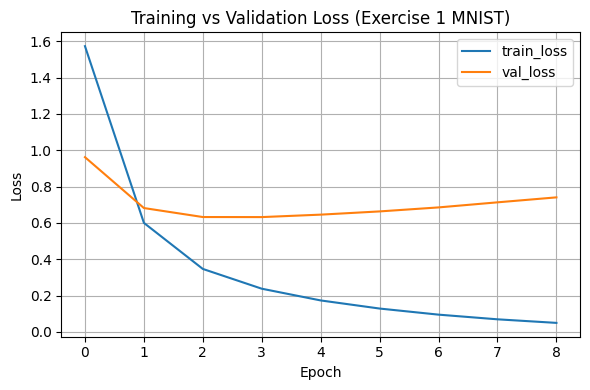

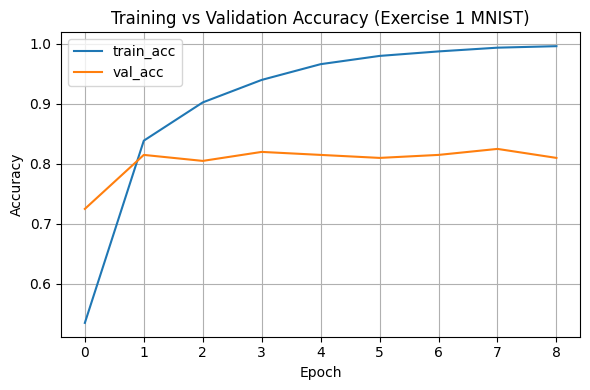

In [2]:
# ---------------------------
# 1) Reproducibility / seeds
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------
# 2) Load MNIST via tf.keras
# ---------------------------
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

# ---------------------------
# 3) Normalize to [0,1] float32
# ---------------------------
X_train_full = X_train_full.astype("float32") / 255.0
X_test_full  = X_test_full.astype("float32") / 255.0

# ---------------------------
# 4) Use only the first 1000 train and first 200 test samples
# ---------------------------
X_small  = X_train_full[:1000]
y_small  = y_train_full[:1000]

X_test   = X_test_full[:200]
y_test   = y_test_full[:200]

# ---------------------------
# 5) Build the Sequential model
# ---------------------------
model = tf.keras.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28), name="flatten"),
        tf.keras.layers.Dense(64, activation="elu", kernel_initializer="he_normal", name="hidden_1"),
        tf.keras.layers.Dense(64, activation="elu", kernel_initializer="he_normal", name="hidden_2"),
        tf.keras.layers.Dense(64, activation="elu", kernel_initializer="he_normal", name="hidden_3"),
        tf.keras.layers.Dense(10, activation="softmax", name="output"),
    ],
    name="mnist_mlp_ex1_tfkeras",
)

# ---------------------------
# 6) Compile: Nadam optimizer, sparse categorical crossentropy, track accuracy
# ---------------------------
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# ---------------------------
# 7) EarlyStopping callback (monitor validation loss)
# ---------------------------
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

# ---------------------------
# 8) Train the model
# ---------------------------
history = model.fit(
    X_small,
    y_small,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_cb],
    verbose=2,
)

# ---------------------------
# 9) Evaluate on the small test set and print accuracy
# ---------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test set accuracy: {test_acc * 100:.2f}%")

# ---------------------------
# 10) Plot training and validation loss curves
# ---------------------------
# Plot loss
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history.get("val_loss", []), label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Exercise 1 MNIST)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot accuracy (hvis du har metrics=['accuracy'])
if "accuracy" in history.history:
    plt.figure(figsize=(6,4))
    plt.plot(history.history["accuracy"], label="train_acc")
    if "val_accuracy" in history.history:
        plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy (Exercise 1 MNIST)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Q 1.1
The obtained test accuracy is 89,5 %

# Exercise 2

Model: "cifar10_mlp_ex2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 986,634 (3.76 MB)

 Trainable params: 986,634 (3.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
32/32 - 2s - 63ms/step - accuracy: 0.1523 - loss: 3.3702 - val_accuracy: 0.2160 - val_loss: 2.1738
Epoch 2/50
32/32 - 0s - 10ms/step - accuracy: 0.2592 - loss: 2.0195 - val_accuracy: 0.2230 - val_loss: 2.0800
Epoch 3/50
32/32 - 0s - 11ms/step - accuracy: 0.3135 - loss: 1.9014 - val_accuracy: 0.2550 - val_loss: 2.0576
Epoch 4/50
32/32 - 0s - 10ms/step - accuracy: 0.3475 - loss: 1.8189 - val_accuracy: 0.2830 - val_loss: 2.0422
Epoch 5/50
32/32 - 0s - 10ms/step - accuracy: 0.3738 - loss: 1.7576 - val_accuracy: 0.3180 - val_loss: 1.9814
Epoch 6/50
32/32 - 0s - 10ms/step - accuracy: 0.3935 - loss: 1.7034 - val_accuracy: 0.3240 - val_loss: 1.9167
Epoch 7/50
32/32 - 0s - 12ms/step - accuracy: 0.4053 - loss: 1.6519 - val_accuracy: 0.3480 - val_loss: 1.8721
Epoch 8/50
32/32 - 0s - 10ms/step - accuracy: 0.4240 - loss: 1.6039 - val_accuracy: 0.3620 - val_loss: 1.8396
Epoch 9/50
32/32 - 0s - 10ms/step - accuracy: 0.4480 - loss: 1.5426 - val_accuracy: 0.3570 - val_loss: 1.8584
Epoch 10/5

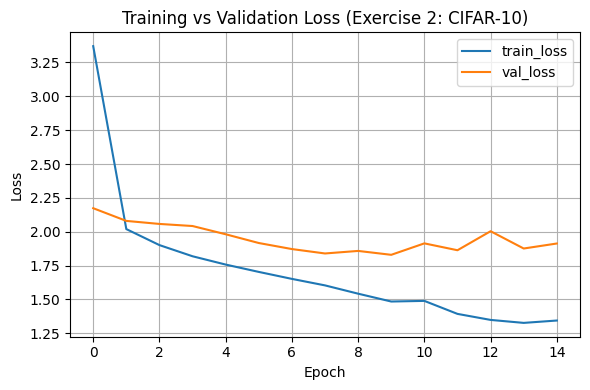

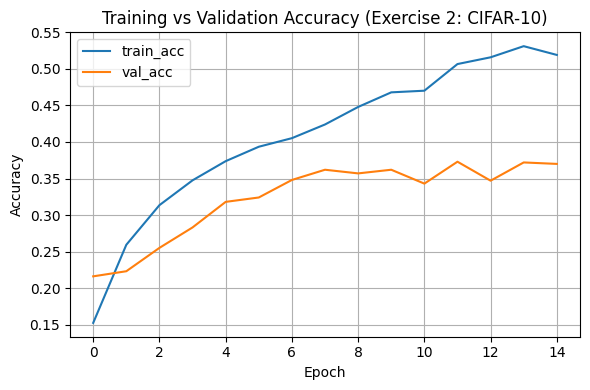

In [3]:
# ---------------------------
# 1) Reproducibility: set seeds
# ---------------------------
SEED = 42
random.seed(SEED)            # Python RNG
np.random.seed(SEED)         # NumPy RNG
tf.random.set_seed(SEED)     # TensorFlow RNG

# ---------------------------
# 2) Load CIFAR-10 via tf.keras
# ---------------------------
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

# ---------------------------
# 3) Convert labels shape and normalize images to [0,1]
# ---------------------------
y_train_full = y_train_full.reshape(-1)
y_test_full = y_test_full.reshape(-1)

# Convert to float32 and scale pixel values to [0,1]
X_train_full = X_train_full.astype("float32") / 255.0
X_test_full  = X_test_full.astype("float32") / 255.0

# ---------------------------
# 4) Use the specified subset
#    - first 5000 training samples
#    - first 1000 test samples
# ---------------------------
X_small = X_train_full[:5000]
y_small = y_train_full[:5000]

X_test  = X_test_full[:1000]
y_test  = y_test_full[:1000]

# ---------------------------
# 5) Building the model in a function
#    - Flatten input_shape=(32,32,3)
#    - 4 hidden Dense layers with 256 units each
#    - ELU activations, He normal initializer
#    - Output Dense(10) with softmax
# ---------------------------
def build_cifar10_mlp():
    model = tf.keras.Sequential(
        [
            # Flatten 32x32x3 -> 3072 features
            tf.keras.layers.Flatten(input_shape=(32, 32, 3), name="flatten"),

            # Hidden layer 1
            tf.keras.layers.Dense(
                256,
                activation="elu",
                kernel_initializer="he_normal",
                name="hidden_1",
            ),

            # Hidden layer 2
            tf.keras.layers.Dense(
                256,
                activation="elu",
                kernel_initializer="he_normal",
                name="hidden_2",
            ),

            # Hidden layer 3
            tf.keras.layers.Dense(
                256,
                activation="elu",
                kernel_initializer="he_normal",
                name="hidden_3",
            ),

            # Hidden layer 4
            tf.keras.layers.Dense(
                256,
                activation="elu",
                kernel_initializer="he_normal",
                name="hidden_4",
            ),

            # Output layer: 10 classes, softmax to produce probabilities
            tf.keras.layers.Dense(10, activation="softmax", name="output"),
        ],
        name="cifar10_mlp_ex2",
    )

    # Compile the model with Nadam (lr=0.001) and sparse categorical crossentropy.
    optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# Instantiate the model
model = build_cifar10_mlp()
model.summary()

# ---------------------------
# 6) EarlyStopping callback (monitor val_loss, patience=5)
# ---------------------------
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

# ---------------------------
# 7) Train the model
#    - epochs=50
#    - batch_size=128
#    - validation_data (explicit)
# ---------------------------
history = model.fit(
    X_small,
    y_small,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[early_stopping_cb],
    verbose=2,
)

# ---------------------------
# 8) Evaluate on the specified small test set (first 1000 samples)
# ---------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test set accuracy: {test_acc * 100:.2f}%")  # report this number for Q2.1

# ---------------------------
# 9) Plot training and validation loss curves
# ---------------------------
# Plot loss
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history.get("val_loss", []), label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Exercise 2: CIFAR-10)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot accuracy (hvis du har metrics=['accuracy'])
if "accuracy" in history.history:
    plt.figure(figsize=(6,4))
    plt.plot(history.history["accuracy"], label="train_acc")
    if "val_accuracy" in history.history:
        plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy (Exercise 2: CIFAR-10)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Q 2.1
The test set accuracy is at 36,2 %

# Exercise 3

Epoch 1/50
25/25 - 2s - 74ms/step - accuracy: 0.2300 - loss: 2.3075 - val_accuracy: 0.7150 - val_loss: 0.9913
Epoch 2/50
25/25 - 0s - 5ms/step - accuracy: 0.5525 - loss: 1.3829 - val_accuracy: 0.8050 - val_loss: 0.6804
Epoch 3/50
25/25 - 0s - 6ms/step - accuracy: 0.6862 - loss: 0.9354 - val_accuracy: 0.8100 - val_loss: 0.6099
Epoch 4/50
25/25 - 0s - 6ms/step - accuracy: 0.7525 - loss: 0.7433 - val_accuracy: 0.8250 - val_loss: 0.5806
Epoch 5/50
25/25 - 0s - 5ms/step - accuracy: 0.7713 - loss: 0.6620 - val_accuracy: 0.8400 - val_loss: 0.6038
Epoch 6/50
25/25 - 0s - 5ms/step - accuracy: 0.8100 - loss: 0.5963 - val_accuracy: 0.8400 - val_loss: 0.5961
Epoch 7/50
25/25 - 0s - 5ms/step - accuracy: 0.8413 - loss: 0.4823 - val_accuracy: 0.8550 - val_loss: 0.5860
Epoch 8/50
25/25 - 0s - 5ms/step - accuracy: 0.8637 - loss: 0.4085 - val_accuracy: 0.8400 - val_loss: 0.6302
Epoch 9/50
25/25 - 0s - 6ms/step - accuracy: 0.8712 - loss: 0.3791 - val_accuracy: 0.8500 - val_loss: 0.6275

Test accuracy (wi

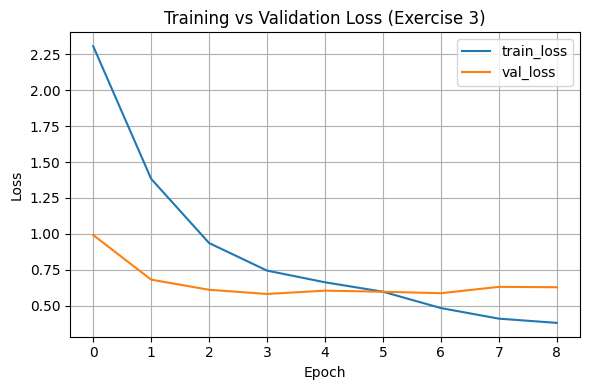

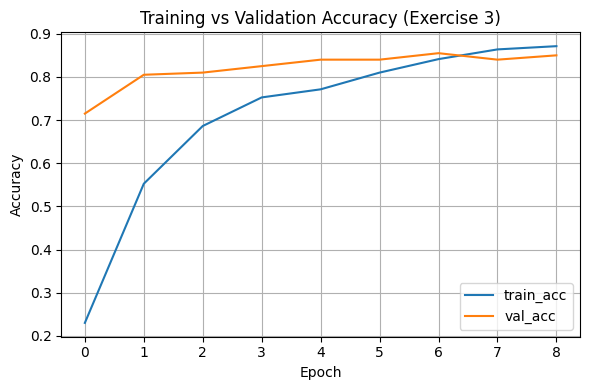

In [4]:
# ---------------------------
# 1) Reproducibility / seeds
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------
# 2) Load MNIST via tf.keras
# ---------------------------
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

# ---------------------------
# 3) Normalize to [0,1] float32
# ---------------------------
X_train_full = X_train_full.astype("float32") / 255.0
X_test_full  = X_test_full.astype("float32")  / 255.0

# ---------------------------
# 4) Use only the first 1000 train and first 200 test samples
# ---------------------------
X_small  = X_train_full[:1000]
y_small  = y_train_full[:1000]

X_test   = X_test_full[:200]
y_test   = y_test_full[:200]

# ---------------------------
# 5) Build the Sequential model (SELU + AlphaDropout + LeCun normal)
# ---------------------------
model = tf.keras.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28), name="flatten"),

        tf.keras.layers.Dense(64, activation="selu",
                              kernel_initializer="lecun_normal",
                              name="hidden_1"),
        tf.keras.layers.AlphaDropout(0.1, name="alpha_dropout_1"),

        tf.keras.layers.Dense(64, activation="selu",
                              kernel_initializer="lecun_normal",
                              name="hidden_2"),
        tf.keras.layers.AlphaDropout(0.1, name="alpha_dropout_2"),

        tf.keras.layers.Dense(64, activation="selu",
                              kernel_initializer="lecun_normal",
                              name="hidden_3"),
        tf.keras.layers.AlphaDropout(0.1, name="alpha_dropout_3"),

        tf.keras.layers.Dense(10, activation="softmax", name="output"),
    ],
    name="mnist_mlp_ex3_tfkeras",
)

# ---------------------------
# 6) Compile: Nadam optimizer, sparse categorical crossentropy, track accuracy
# ---------------------------
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# ---------------------------
# 7.1) EarlyStopping callback (monitor validation loss)
# ---------------------------
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

# ---------------------------
# 7.2) Training the model
# ---------------------------
history = model.fit(
    X_small,
    y_small,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_cb],
    verbose=2,
)

# ---------------------------
# 8) Evaluate normally (Dropout OFF during inference)
# ---------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest accuracy (without MC Dropout): {test_acc * 100:.2f}%")

# ---------------------------
# 9) Monte Carlo Dropout (Dropout ON during inference)
# ---------------------------
def mc_dropout_predict(model, X, passes=20):
    """Runs forward passes with dropout active (training=True)"""
    preds = []
    for _ in range(passes):
        y_prob = model(X, training=True)  # <--- forces dropout ON
        preds.append(y_prob.numpy())
    return np.stack(preds, axis=0)

mc_preds = mc_dropout_predict(model, X_test, passes=20)
mc_mean  = mc_preds.mean(axis=0)                       # average softmax
mc_pred_labels = np.argmax(mc_mean, axis=1)            # final prediction
mc_acc = np.mean(mc_pred_labels == y_test)

print(f"Test accuracy (MC Dropout, 20 passes): {mc_acc * 100:.2f}%")

# ---------------------------
# 10) Plot training & validation loss curves
# ---------------------------

# Plot loss
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history.get("val_loss", []), label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Exercise 3)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot accuracy (hvis du har metrics=['accuracy'])
if "accuracy" in history.history:
    plt.figure(figsize=(6,4))
    plt.plot(history.history["accuracy"], label="train_acc")
    if "val_accuracy" in history.history:
        plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy (Exercise 3)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Q 3.1
Test accuracy is 82 % with Alpha Dropout applied during trainging.

## Q 3.2
Test accuracy is 80,5 % when using MC dropout without retraining.

# Exercise 4

Model: "mobilenetv2_transfer_ex4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
50/50 - 8s - 169ms/step - accuracy: 0.4881 - loss: 1.4400 - val_accuracy: 0.6575 - val_loss: 1.0513
Epoch 2/5
50/50 - 4s - 72ms/step - accuracy: 0.7025 - loss: 0.8190 - val_accuracy: 0.6975 - val_loss: 0.9595
Epoch 3/5
50/50 - 4s - 70ms/step - accuracy: 0.7844 - loss: 0.6199 - val_accuracy: 0.6950 - val_loss: 0.8974
Epoch 4/5
50/50 - 4s - 74ms/step - accuracy: 0.8363 - loss: 0.4956 - val_accuracy: 0.7200 - val_loss: 0.8906
Epoch 5/5
50/50 - 3s - 66ms/step - accuracy: 0.8562 - loss: 0.4262 - val_accuracy: 0.7300 - val_loss: 0.8215

Test set accuracy: 70.00%


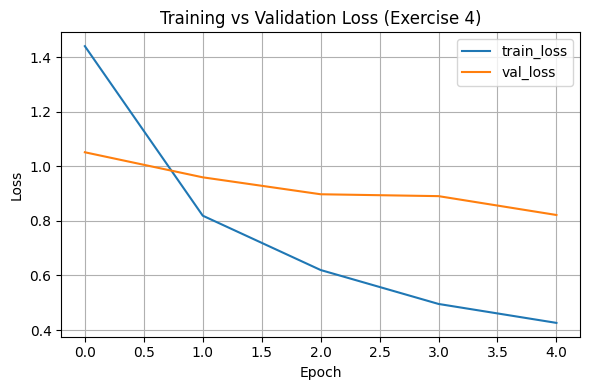

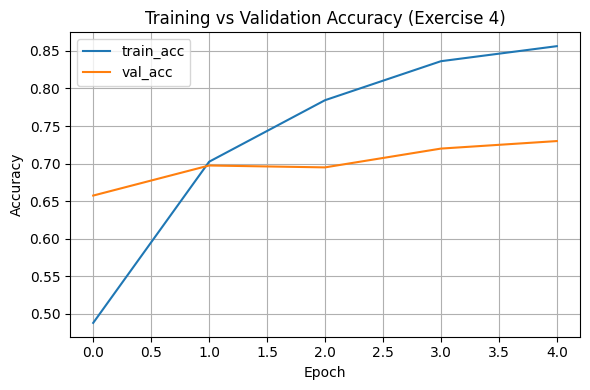

In [5]:
# ---------------------------
# 1) Reproducibility / seeds
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------
# 2) Load CIFAR-10 and normalize to [0,1]
# ---------------------------
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

# Flatten label arrays to shape (N,)
y_train_full = y_train_full.reshape(-1)
y_test_full  = y_test_full.reshape(-1)

# Convert dtype and scale pixels to [0,1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test_full  = x_test_full.astype("float32")  / 255.0

# ---------------------------
# 3) Use only first 2000 train and first 500 test samples
# ---------------------------
X_small = x_train_full[:2000]
y_small = y_train_full[:2000]

X_test  = x_test_full[:500]
y_test  = y_test_full[:500]

# ---------------------------
# 4) Resize images to MobileNetV2 input size
# ---------------------------
# IMG_SIZE = 32  # Original size, and results in 25,6 % accuracy
IMG_SIZE = 96   # Faster
# IMG_SIZE = 224  # Slower, and results in 67,8 % accuracy

def resize_images(images, size=IMG_SIZE):
    # images: numpy array (N, h, w, c) in [0,1]
    # returns float32 resized images
    images_tf = tf.image.resize(images, (size, size), method="bilinear")
    return images_tf.numpy()

X_train_resized = resize_images(X_small)
X_test_resized  = resize_images(X_test)

# ---------------------------
# 5) Build transfer learning model using MobileNetV2 base
# ---------------------------
from tensorflow.keras import layers, models, optimizers, applications

# Load MobileNetV2 base with imagenet weights, exclude top classifier
base_model = applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)

# Freeze all layers of the pre-trained base
base_model.trainable = False

# Build the top classifier as specified
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")
x = base_model(inputs, training=False)                   
x = layers.GlobalAveragePooling2D(name="gap")(x)         
x = layers.Dense(128, activation="relu", name="dense_128")(x)
x = layers.Dropout(0.2, name="dropout")(x)
outputs = layers.Dense(10, activation="softmax", name="output")(x)

model = models.Model(inputs, outputs, name="mobilenetv2_transfer_ex4")

# ---------------------------
# 6) Compile: Adam lr=0.001, sparse categorical crossentropy
# ---------------------------
optimizer = optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# ---------------------------
# 7) Train for 5 epochs, batch_size=32
# ---------------------------
history = model.fit(
    X_train_resized, y_small,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    verbose=2
)

# ---------------------------
# 8) Evaluate on the test subset
# ---------------------------
test_loss, test_acc = model.evaluate(X_test_resized, y_test, verbose=0)
print(f"\nTest set accuracy: {test_acc * 100:.2f}%")

# ---------------------------
# 9) Plot training and validation loss curves
# ---------------------------
# Plot loss
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history.get("val_loss", []), label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Exercise 4)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot accuracy (hvis du har metrics=['accuracy'])
if "accuracy" in history.history:
    plt.figure(figsize=(6,4))
    plt.plot(history.history["accuracy"], label="train_acc")
    if "val_accuracy" in history.history:
        plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy (Exercise 4)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Q 4.1
The test set accuracy for this model is 70 %, with input image set to (96,96) in size.

# Exercise 5

c:\Users\hanse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "svhn_cnn_ex5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,994 (1.82 MB)

 Trainable params: 477,994 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
50/50 - 2s - 41ms/step - accuracy: 0.2019 - loss: 2.2484 - val_accuracy: 0.1850 - val_loss: 2.2589
Epoch 2/15
50/50 - 1s - 11ms/step - accuracy: 0.2050 - loss: 2.2286 - val_accuracy: 0.1850 - val_loss: 2.2580
Epoch 3/15
50/50 - 1s - 11ms/step - accuracy: 0.2087 - loss: 2.2277 - val_accuracy: 0.1850 - val_loss: 2.2519
Epoch 4/15
50/50 - 1s - 10ms/step - accuracy: 0.2087 - loss: 2.2193 - val_accuracy: 0.1850 - val_loss: 2.2303
Epoch 5/15
50/50 - 1s - 11ms/step - accuracy: 0.2338 - loss: 2.1474 - val_accuracy: 0.3500 - val_loss: 1.9693
Epoch 6/15
50/50 - 1s - 11ms/step - accuracy: 0.4475 - loss: 1.6440 - val_accuracy: 0.6075 - val_loss: 1.2308
Epoch 7/15
50/50 - 1s - 11ms/step - accuracy: 0.6106 - loss: 1.1727 - val_accuracy: 0.6475 - val_loss: 1.0097
Epoch 8/15
50/50 - 1s - 10ms/step - accuracy: 0.6700 - loss: 1.0227 - val_accuracy: 0.7250 - val_loss: 0.8761
Epoch 9/15
50/50 - 1s - 11ms/step - accuracy: 0.7275 - loss: 0.8629 - val_accuracy: 0.7725 - val_loss: 0.7857
Epoch 10/1

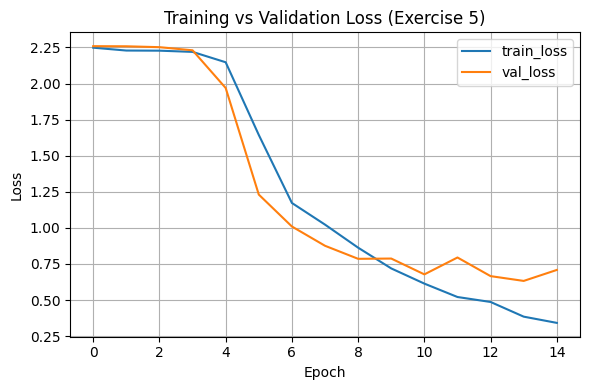

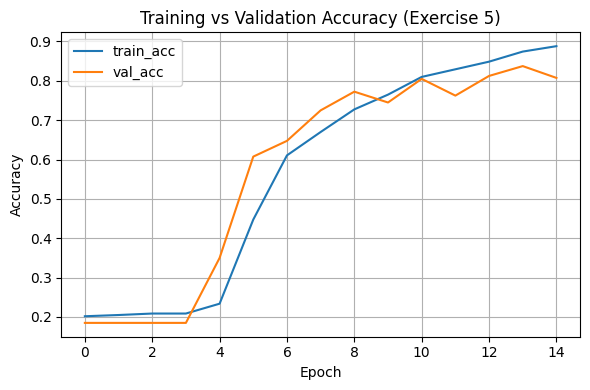

In [6]:
import scipy.io

# ---------------------------
# 1) Reproducibility
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------
# 2) Download + load SVHN via cache
# ---------------------------
train_path = tf.keras.utils.get_file(
    "train_32x32.mat",
    origin="http://ufldl.stanford.edu/housenumbers/train_32x32.mat",
)
test_path = tf.keras.utils.get_file(
    "test_32x32.mat",
    origin="http://ufldl.stanford.edu/housenumbers/test_32x32.mat",
)

train = scipy.io.loadmat(train_path)
test  = scipy.io.loadmat(test_path)

# 'X' shape: (32, 32, 3, n) -> transpose to (n, 32, 32, 3)
X_train_full = np.transpose(train["X"], (3, 0, 1, 2))
y_train_full = train["y"].reshape(-1)

X_test_full = np.transpose(test["X"], (3, 0, 1, 2))
y_test_full = test["y"].reshape(-1)

# label 10 means digit "0" -> map 10 -> 0
y_train_full[y_train_full == 10] = 0
y_test_full[y_test_full == 10] = 0

# ---------------------------
# 3) Normalize pixel values
# ---------------------------
X_train_full = X_train_full.astype("float32") / 255.0
X_test_full  = X_test_full.astype("float32") / 255.0

# ---------------------------
# 4) Use subset: 2000 train, 500 test
# ---------------------------
X_train = X_train_full[:2000]
y_train = y_train_full[:2000]

X_test  = X_test_full[:500]
y_test  = y_test_full[:500]

# ---------------------------
# 5) Build CNN model, with given architecture
# ---------------------------
model = tf.keras.Sequential(
    [
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
        tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(10, activation="softmax"),
    ],
    name="svhn_cnn_ex5"
)

model.summary()

# ---------------------------
# 6) Compile model
# ---------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# ---------------------------
# 7) Train (15 epochs, batch size = 32)
# ---------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=2
)

# ---------------------------
# 8) Evaluate on test subset
# ---------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy (SVHN CNN - Exercise 5): {test_acc * 100:.2f}%")

# ---------------------------
# 9) Plot training and validation loss curves
# ---------------------------
# Plot loss
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history.get("val_loss", []), label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Exercise 5)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot accuracy (hvis du har metrics=['accuracy'])
if "accuracy" in history.history:
    plt.figure(figsize=(6,4))
    plt.plot(history.history["accuracy"], label="train_acc")
    if "val_accuracy" in history.history:
        plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy (Exercise 5)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Q 5.1
The test accuracy of the deeper CNN model is 73,8 %

# Exercise 6

Model: "svhn_cnn_ex6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
50/50 - 1s - 24ms/step - accuracy: 0.1931 - loss: 2.2480 - val_accuracy: 0.1850 - val_loss: 2.2565
Epoch 2/15
50/50 - 0s - 8ms/step - accuracy: 0.2081 - loss: 2.2255 - val_accuracy: 0.1850 - val_loss: 2.2499
Epoch 3/15
50/50 - 0s - 8ms/step - accuracy: 0.2087 - loss: 2.2201 - val_accuracy: 0.1850 - val_loss: 2.2456
Epoch 4/15
50/50 - 0s - 8ms/step - accuracy: 0.2087 - loss: 2.2162 - val_accuracy: 0.1850 - val_loss: 2.2431
Epoch 5/15
50/50 - 0s - 9ms/step - accuracy: 0.2087 - loss: 2.2132 - val_accuracy: 0.1850 - val_loss: 2.2404
Epoch 6/15
50/50 - 0s - 9ms/step - accuracy: 0.2087 - loss: 2.2088 - val_accuracy: 0.1850 - val_loss: 2.2346
Epoch 7/15
50/50 - 0s - 8ms/step - accuracy: 0.2087 - loss: 2.1987 - val_accuracy: 0.1850 - val_loss: 2.2259
Epoch 8/15
50/50 - 0s - 8ms/step - accuracy: 0.2094 - loss: 2.1779 - val_accuracy: 0.1850 - val_loss: 2.1987
Epoch 9/15
50/50 - 0s - 8ms/step - accuracy: 0.2300 - loss: 2.1351 - val_accuracy: 0.2175 - val_loss: 2.1561
Epoch 10/15
50/50 

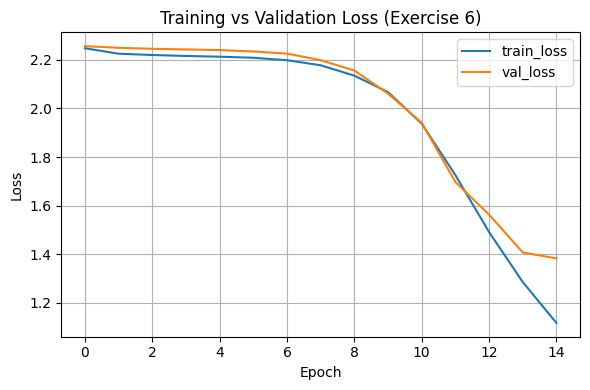

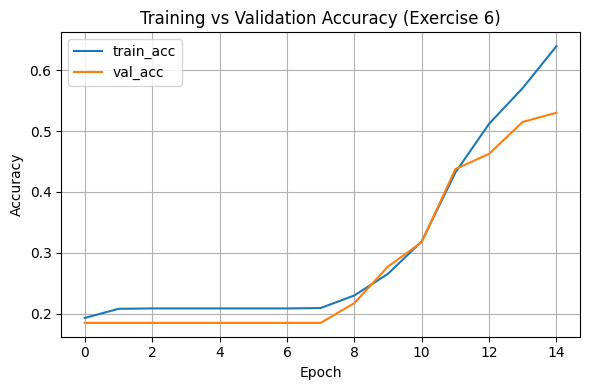

In [7]:
# ---------------------------
# 1) Reproducibility / seeds
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------
# 2) Download + load SVHN via cache
# ---------------------------
train_path = tf.keras.utils.get_file(
    "train_32x32.mat",
    origin="http://ufldl.stanford.edu/housenumbers/train_32x32.mat",
)
test_path = tf.keras.utils.get_file(
    "test_32x32.mat",
    origin="http://ufldl.stanford.edu/housenumbers/test_32x32.mat",
)

train = scipy.io.loadmat(train_path)
test  = scipy.io.loadmat(test_path)

# X: (32, 32, 3, N) -> (N, 32, 32, 3)
X_train_full = np.transpose(train["X"], (3, 0, 1, 2))
y_train_full = train["y"].reshape(-1)

X_test_full  = np.transpose(test["X"], (3, 0, 1, 2))
y_test_full  = test["y"].reshape(-1)

# SVHN uses label "10" for digit 0 -> map 10 -> 0
y_train_full[y_train_full == 10] = 0
y_test_full[y_test_full == 10] = 0

# ---------------------------
# 3) Normalize to [0,1]
# ---------------------------
X_train_full = X_train_full.astype("float32") / 255.0
X_test_full  = X_test_full.astype("float32")  / 255.0

# ---------------------------
# 4) Use subset: 2000 train, 500 test
# ---------------------------
X_train = X_train_full[:2000]
y_train = y_train_full[:2000]

X_test  = X_test_full[:500]
y_test  = y_test_full[:500]

# ---------------------------
# 5) Build CNN model, with given architecture
# ---------------------------
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(32, 32, 3)),
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(10, activation="softmax"),
    ],
    name="svhn_cnn_ex6",
)

model.summary()

# ---------------------------
# 6) Compile with SGD + momentum
# ---------------------------
optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9,
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# ---------------------------
# 7) Train (15 epochs, batch size 32)
# ---------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=2,
)

# ---------------------------
# 8) Standard test accuracy (dropout OFF)
# ---------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy (no MC Dropout): {test_acc * 100:.2f}%")

# ---------------------------
# 9) MC Dropout: enable dropout at inference
# ---------------------------
num_passes = 20

mc_probas = np.stack(
    [model(X_test, training=True).numpy() for _ in range(num_passes)],
    axis=0
)  # shape: (T, N, 10)

mc_mean = mc_probas.mean(axis=0)              # (N, 10)
mc_pred = np.argmax(mc_mean, axis=1)          # (N,)

mc_acc = np.mean(mc_pred == y_test)
print(f"Test accuracy (MC Dropout, {num_passes} passes): {mc_acc * 100:.2f}%")

# ---------------------------
# 10) Epistemic uncertainty (simple estimate)
#     Here: mean variance over classes per sample, averaged over dataset
# ---------------------------
mc_var = mc_probas.var(axis=0)                # (N, 10)
epistemic_per_sample = mc_var.mean(axis=1)    # (N,)
mean_epistemic_uncertainty = epistemic_per_sample.mean()

print(f"Mean epistemic uncertainty (variance-based): {mean_epistemic_uncertainty:.6f}")

# ---------------------------
# 11) Plot training and validation loss curves
# ---------------------------
# Plot loss
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history.get("val_loss", []), label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Exercise 6)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot accuracy (hvis du har metrics=['accuracy'])
if "accuracy" in history.history:
    plt.figure(figsize=(6,4))
    plt.plot(history.history["accuracy"], label="train_acc")
    if "val_accuracy" in history.history:
        plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy (Exercise 6)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Q 6.1
The plain test accuracy without MC-dropout is 54,6 %

## Q 6.2
Accuracy with MC-dropout is 53,8 %

## Q 6.3
The mean epistemic accuracy across all test samples is 0.003 (rounded)